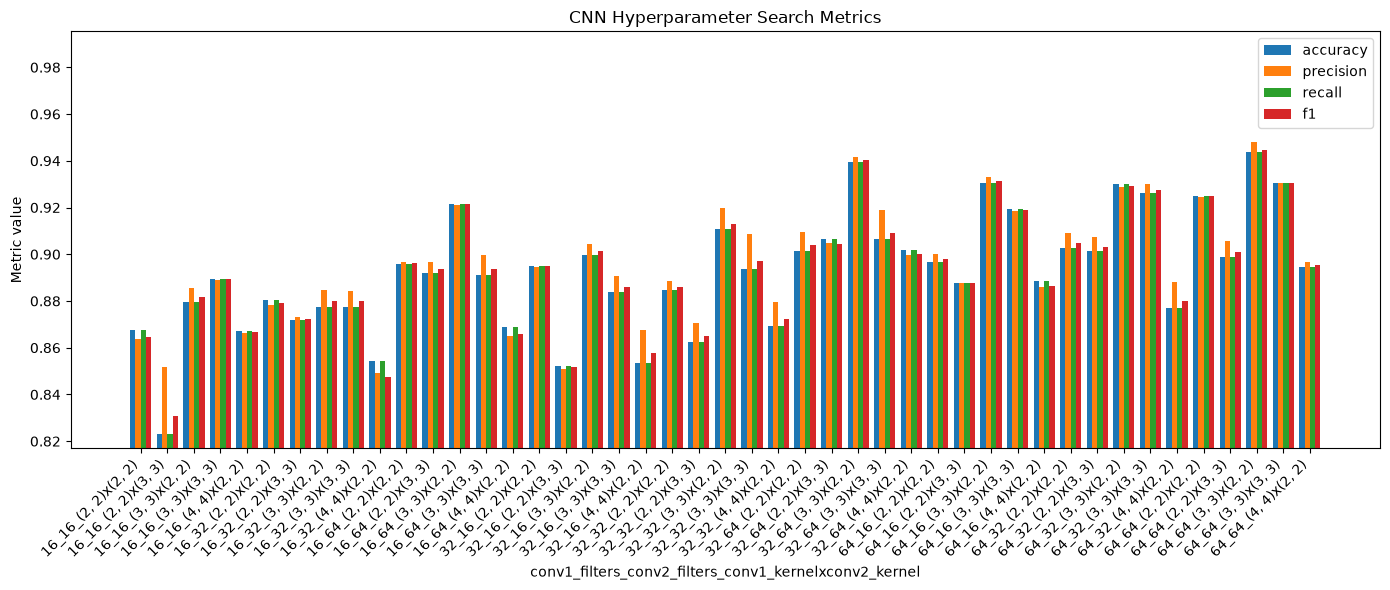

In [77]:
import pandas as pd

import matplotlib.pyplot as plt

df = pd.read_csv("cnn_hyperparameter_search.csv")

df["config_label"] = (
    df["conv1_filters"].astype(str)
    + "_"
    + df["conv2_filters"].astype(str)
    + "_"
    + df["conv1_kernel"].astype(str)
    + "x"
    + df["conv2_kernel"].astype(str)
)

metrics = ["accuracy", "precision", "recall", "f1"]

df[metrics] = df[metrics].apply(pd.to_numeric, errors="coerce")
plot_df = df.dropna(subset=metrics).sort_values("config_label")

x = range(len(plot_df))
width = 0.2

plt.figure(figsize=(14, 6))
for i, metric in enumerate(metrics):
    plt.bar(
        [pos + i * width for pos in x],
        plot_df[metric],
        width=width,
        label=metric,
    )

min_value = plot_df[metrics].min().min()
padding = (plot_df[metrics].max().max() - min_value) * 0.05
plt.ylim(min_value - abs(padding), None)

plt.xticks([pos + width * (len(metrics) - 1) / 2 for pos in x], plot_df["config_label"], rotation=45, ha="right")
plt.xlabel("conv1_filters_conv2_filters_conv1_kernelxconv2_kernel")
plt.ylabel("Metric value")
plt.title("CNN Hyperparameter Search Metrics")
plt.legend()
plt.tight_layout()
plt.show()

Average F1: 0.8935
Architectures above average: 25/45


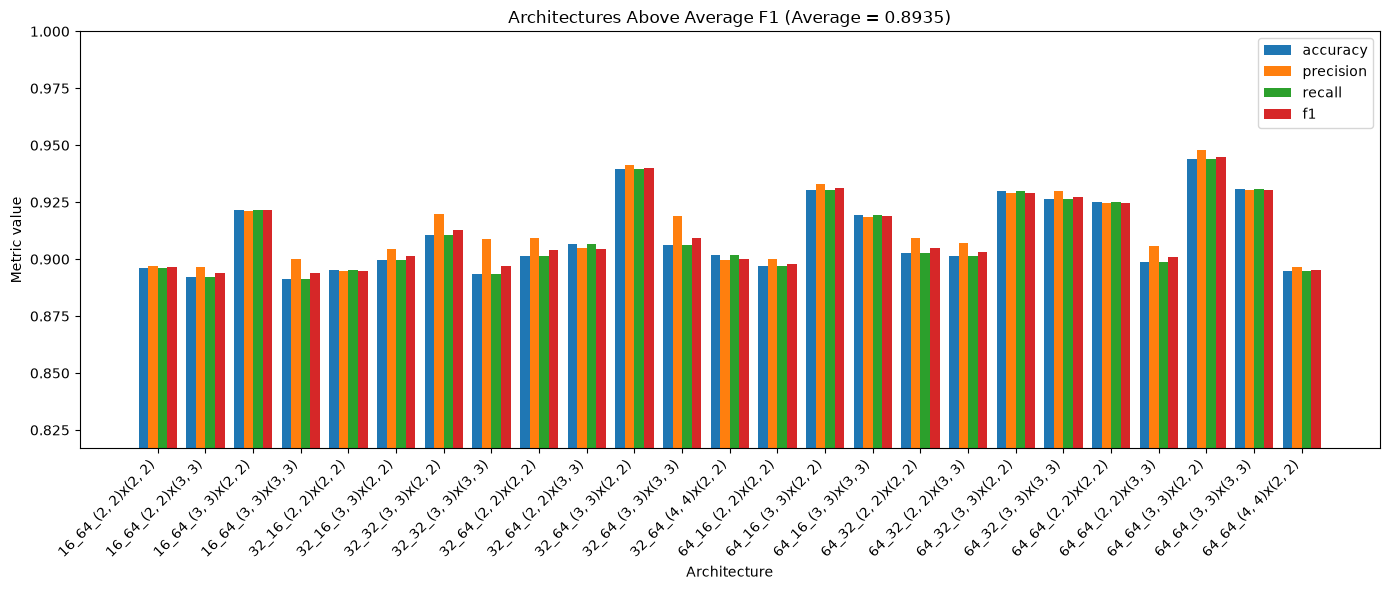

In [78]:
# ==========================================================
# Plot architectures with above-average F1
# ==========================================================

average_f1 = plot_df["f1"].mean()

above_average = plot_df[plot_df["f1"] > average_f1].copy()

print(f"Average F1: {average_f1:.4f}")
print(f"Architectures above average: {len(above_average)}/{len(plot_df)}")

#above_average = above_average.sort_values("f1", ascending=False)

x = range(len(above_average))
width = 0.2

plt.figure(figsize=(14,6))

min_value = plot_df[metrics].min().min()
padding = (plot_df[metrics].max().max() - min_value) * 0.05
plt.ylim(min_value - abs(padding), None)

for i, metric in enumerate(metrics):
    plt.bar(
        [p + i*width for p in x],
        above_average[metric],
        width=width,
        label=metric,
    )

plt.xticks(
    [p + width*(len(metrics)-1)/2 for p in x],
    above_average["config_label"],
    rotation=45,
    ha="right",
)

plt.ylabel("Metric value")
plt.xlabel("Architecture")
plt.title(f"Architectures Above Average F1 (Average = {average_f1:.4f})")
plt.legend()
plt.tight_layout()
plt.show()

In [79]:
top = plot_df.nlargest(5, "f1")[["config_label", "accuracy", "precision", "recall", "f1"]]
bottom = plot_df.nsmallest(3, "f1")[["config_label", "accuracy", "precision", "recall", "f1"]]

display(top, bottom)

,config_label,accuracy,precision,recall,f1
0,"64_64_(3, 3)x(2, 2)",0.9438,0.9480,0.9438,0.9448
1,"32_64_(3, 3)x(2, 2)",0.9395,0.9415,0.9395,0.9402
2,"64_16_(3, 3)x(2, 2)",0.9305,0.9329,0.9305,0.9313
3,"64_64_(3, 3)x(3, 3)",0.9307,0.9303,0.9307,0.9305
4,"64_32_(3, 3)x(2, 2)",0.9299,0.9290,0.9299,0.9291


,config_label,accuracy,precision,recall,f1
44,"16_16_(2, 2)x(3, 3)",0.8232,0.8518,0.8232,0.8306
43,"16_32_(4, 4)x(2, 2)",0.8542,0.8490,0.8542,0.8473
42,"32_16_(2, 2)x(3, 3)",0.8524,0.8511,0.8524,0.8517


In [80]:
failed = df[df["status"] == "Failed"][["config_label", "error"]]
display(failed)

,config_label,error
45,"16_16_(2, 2)x(4, 4)",Calculated padded input size per channel: (26 ...
46,"16_16_(3, 3)x(4, 4)",Calculated padded input size per channel: (26 ...
47,"16_16_(4, 4)x(3, 3)",Calculated padded input size per channel: (25 ...
48,"16_16_(4, 4)x(4, 4)",Calculated padded input size per channel: (25 ...
49,"16_32_(2, 2)x(4, 4)",Calculated padded input size per channel: (26 ...
50,"16_32_(3, 3)x(4, 4)",Calculated padded input size per channel: (26 ...
51,"16_32_(4, 4)x(3, 3)",Calculated padded input size per channel: (25 ...
52,"16_32_(4, 4)x(4, 4)",Calculated padded input size per channel: (25 ...
53,"16_64_(2, 2)x(4, 4)",Calculated padded input size per channel: (26 ...
54,"16_64_(3, 3)x(4, 4)",Calculated padded input size per channel: (26 ...
